# Randomized SVD

This notebook implements a randomized SVD workflow and compares it with the exact truncated SVD on a synthetic test matrix with prescribed singular values.

It:
1. builds a matrix $A = U \Sigma V^T$ with prescribed singular values,
2. computes the optimal rank-$k$ approximation from the exact SVD,
3. computes a randomized rank-$k$ approximation,
4. plots the approximation error and the runtime as a function of $k$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
from timeit import default_timer as timer

np.random.seed(42)

In [17]:
# Generate test matrix A with rapidly decaying singular values

def gen_test_matrix(m,n):
    
    size = min(m,n)
    speed = 0.3 # control decay speed of singular values    
    sigma = 1.0 / (np.arange(1, size+1) ** 2)
    
    X = np.random.randn(m, size)
    U, _ = np.linalg.qr(X)
    
    Y = np.random.randn(n, size)
    V, _ = np.linalg.qr(Y)
    
    Sigma = np.diag(sigma)
    
    A = U @ Sigma @ V.T
    
    return A, sigma

In [3]:
# exact rank-k approximation

def svd_rk_k(A,k):
    
    if k >= min(A.shape):
        raise ValueError('k should be smaller than min(m,n)')
    
    U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
    
    U_k = U[:, :k]
    sigma_k = sigma[:k]
    Vt_k = Vt[:k, :]
    
    A_k = U_k @ np.diag(sigma_k) @ Vt_k
    
    return A_k

# approximation error using Eckart-Young

# m,n = 256, 512
# A, sigma = gen_test_matrix(m,n)
# k = 12
# A_k = svd_rk_k(A,k)
# error = np.linalg.norm(A-A_k, ord=2)
# print(error)
# print(sigma[k])

In [4]:
# randomized rank-k approximation

def rand_svd_rk_k(A0,k,c):
    
    m,n0 = A0.shape
    
    if k >= min(m,n0):
        raise ValueError('k should be smaller than min(m,n0)')
    if c >= n0:
        raise ValueError('c should be smaller than n0')
    if k >= c:
        raise ValueError('k should be smaller than c')
    
    # n should be power of 2 for Hadamard transform
    
    if np.log2(n0).is_integer():
        A = A0
    else:
        n = 2 ** int(np.ceil(np.log2(n0)))
        A = np.zeros((m, n))
        A[:, :n0] = A0
    
    m,n = A.shape
    
    # uniform distribution
    p = np.ones(n) / n
    idx = np.random.choice(n, size=c, replace=True, p=p)
    idx = np.sort(idx)
    
    # scaled and permuted subset of identity matrix
    S = np.eye(n)[:, idx] * np.sqrt(n/c)
    
    # normalized Hadamard transform
    H = hadamard(n) / np.sqrt(n)
    
    # random vector ~ Rademacher distribution
    d = np.random.choice([-1, 1], size=n)
    D = np.diag(d)
    
    # sketch
    C = A @ D @ H @ S
    U_c, _ = np.linalg.qr(C)
    
    W = U_c.T @ A
    W_k = svd_rk_k(W,k)
    
    A_k = U_c @ W_k
    
    return A, A_k

# approximation error using Eckart-Young

# m,n0 = 256, 512
# A0, sigma = gen_test_matrix(m,n0)
# k = 3
# c = 6
# A1, A_k = rand_svd_rk_k(A0,k,c)
# error = np.linalg.norm(A1-A_k, ord=2)
# print(error)
# print(sigma[k])

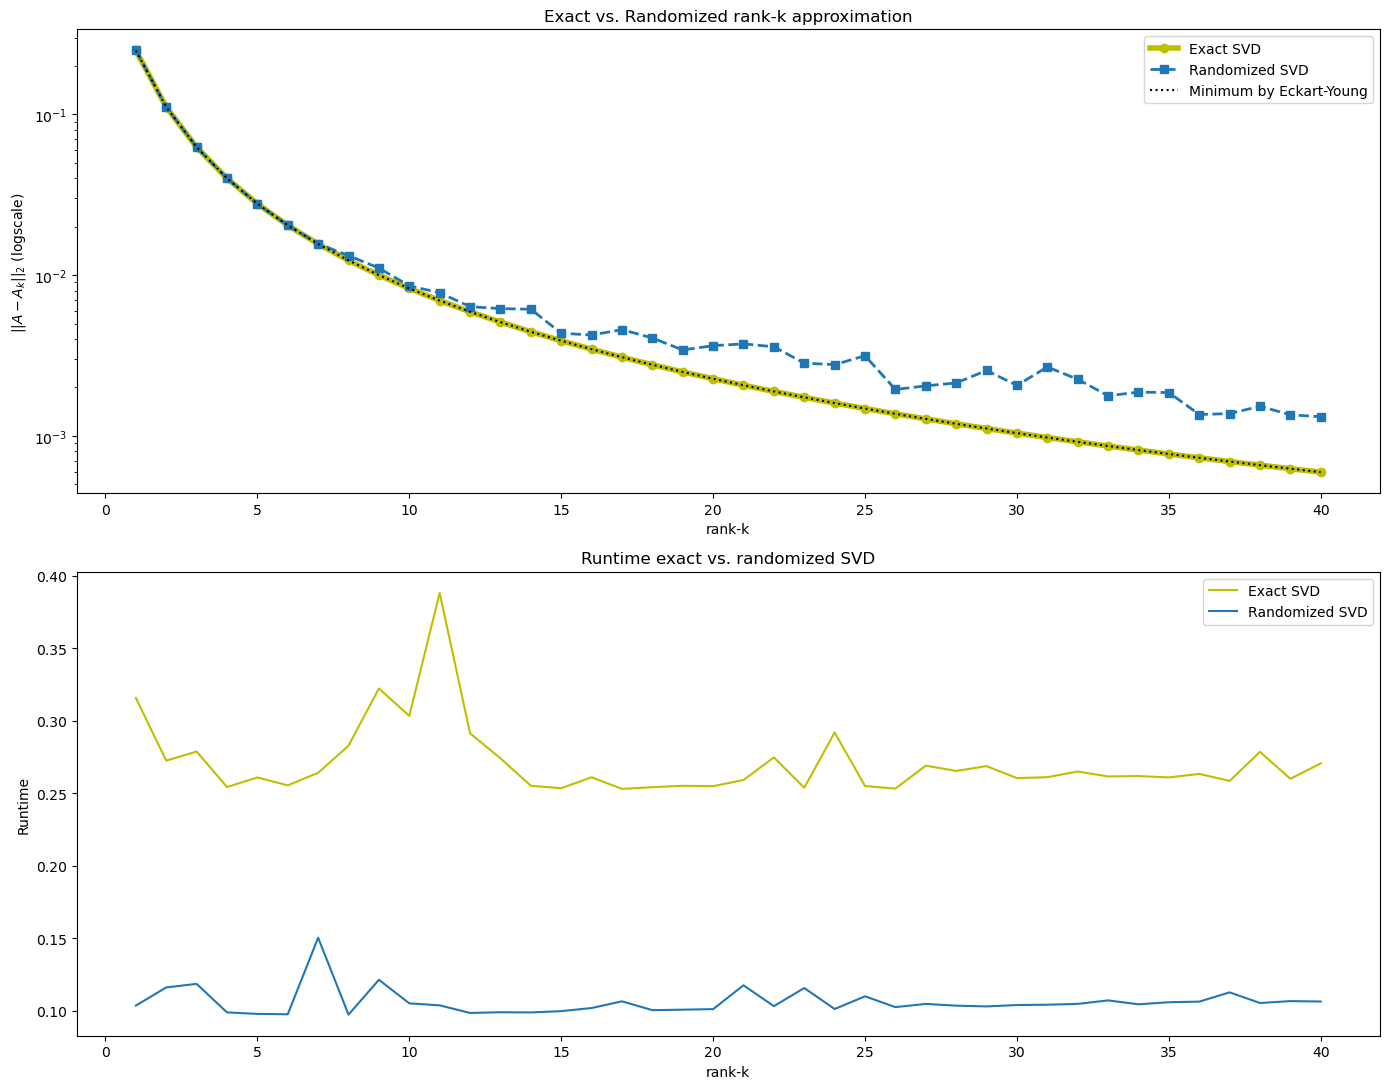

In [21]:
# plot the approximation error using Eckart-Young Theorem

m,n = 1000, 800
A, sigma = gen_test_matrix(m,n)

k_vals = list(range(1,41))

exact_errors, rand_errors, min_errors = [], [], []
exact_runtimes, rand_runtimes = [], []

for k in k_vals:
    
    c = k + 10 # set c larger than k
    
    start1 = timer()
    A_k_exact = svd_rk_k(A,k)
    end1 = timer()
    exact_time = end1 - start1
    exact_runtimes.append(exact_time)
    
    error_exact = np.linalg.norm(A-A_k_exact, ord=2)
    exact_errors.append(error_exact)
    
    start2 = timer()
    A_full, A_k_rand = rand_svd_rk_k(A,k,c)
    end2 = timer()
    rand_time = end2 - start2
    rand_runtimes.append(rand_time)
    
    error_rand = np.linalg.norm(A_full-A_k_rand, ord=2)
    rand_errors.append(error_rand)
    
    min_errors.append(sigma[k])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))
    
ax1.plot(k_vals, exact_errors, 'o-y', label='Exact SVD', linewidth=4.0)
ax1.plot(k_vals, rand_errors, 's--', label='Randomized SVD', linewidth=2.0)
ax1.plot(k_vals, min_errors, 'k:', label='Minimum by Eckart-Young', linewidth=1.5)

ax1.set_yscale('log')
ax1.set_xlabel('rank-k')
ax1.set_ylabel('$||A-A_k||_2$ (logscale)')
ax1.set_title('Exact vs. Randomized rank-k approximation')
ax1.legend(fontsize='medium')

ax2.plot(k_vals, exact_runtimes, c='y', label='Exact SVD')
ax2.plot(k_vals, rand_runtimes, label='Randomized SVD')

ax2.set_xlabel('rank-k')
ax2.set_ylabel('Runtime')
ax2.set_title('Runtime exact vs. randomized SVD')
ax2.legend(fontsize='medium')

plt.tight_layout()
plt.show()